# 1 · Rain generators, flows and evolution

The simulator behind every other notebook of this project: 2-D rain from ten stochastic models
and one physical one, carried by uniform and non-uniform flows, evolving in time - with the
true motion known exactly. Everything here runs in about a minute.

**Contents**
1. Every generator, by name, with any parameter
2. One model, its parameters: covariance, profile, texture
3. Flows
4. Moving and evolving: four evolutions and how predictable they leave the rain
5. A physical model: the warm-rain cloud model
6. Other fields and 1-D fields

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from core import viz_style as vs
%matplotlib inline
vs.use_style()
pd.set_option("display.width", 160)
FIG = Path("../results/figures")
TAB = Path("../results/tables")

from core.simulation import generators as gen, flows as fl, spacetime as st
from core.simulation.rain_fields import Grid, field_stats

## 1. Every generator, by name

`gen.make(key, **params)` takes a model key or a preset (a model with tuned parameters) and
any parameter override. The presets are tuned to a 64 km domain at 0.5 km.

In [2]:
pd.DataFrame([(k, b, ", ".join(f"{a}={v}" for a, v in p.items())) for k, (b, p) in gen.PRESETS.items()],
             columns=["preset", "model", "parameters"])

,preset,model,parameters
0,convective_cells,gaussian_cells,"n_cells=18, radius_km=1.8, peak_mean_mm_h=30, ..."
1,clustered_storms,gaussian_cells,"n_cells=30, n_storms=3, storm_radius_km=5, rad..."
2,squall_line,gaussian_cells,"n_cells=25, n_storms=1, storm_radius_km=3, rad..."
3,stratiform_matern,metagaussian,"cov=matern, length_km=12, nu=1.5, war=0.85, di..."
4,banded_anisotropic,metagaussian,"cov=matern, length_km=6, nu=1.0, anisotropy=4,..."
5,scale_free,metagaussian,"cov=powerlaw, beta=3.2, war=0.5, mean_wet_mm_h..."
6,rainfarm,rainfarm,
7,cascade,cascade,
8,multifractal,multifractal,


In [3]:
grid = Grid(n=128, dx_km=0.5)
keys = ["convective_cells", "clustered_storms", "squall_line", "stratiform_matern",
        "banded_anisotropic", "rainfarm", "cascade", "multifractal"]
fields = {k: gen.make(k, seed=3).build(grid) for k in keys}
stats = pd.DataFrame({k: field_stats(f, grid) for k, f in fields.items()}).T
stats[["war", "imf", "cmf", "max", "decorrelation_km", "frac_flux_top5pct"]].round(2)

,war,imf,cmf,max,decorrelation_km,frac_flux_top5pct
convective_cells,0.22,0.92,4.27,83.58,2.77,0.80
clustered_storms,0.22,2.00,9.07,75.96,4.44,0.70
squall_line,0.24,1.11,4.64,92.32,4.82,0.82
stratiform_matern,0.84,1.70,2.02,15.08,10.30,0.19
banded_anisotropic,0.45,1.80,4.00,94.10,6.48,0.39
rainfarm,0.60,2.00,3.33,34.00,9.17,0.33
cascade,0.79,1.51,1.90,39.93,2.13,0.28
multifractal,0.49,2.00,4.11,28.45,9.96,0.38


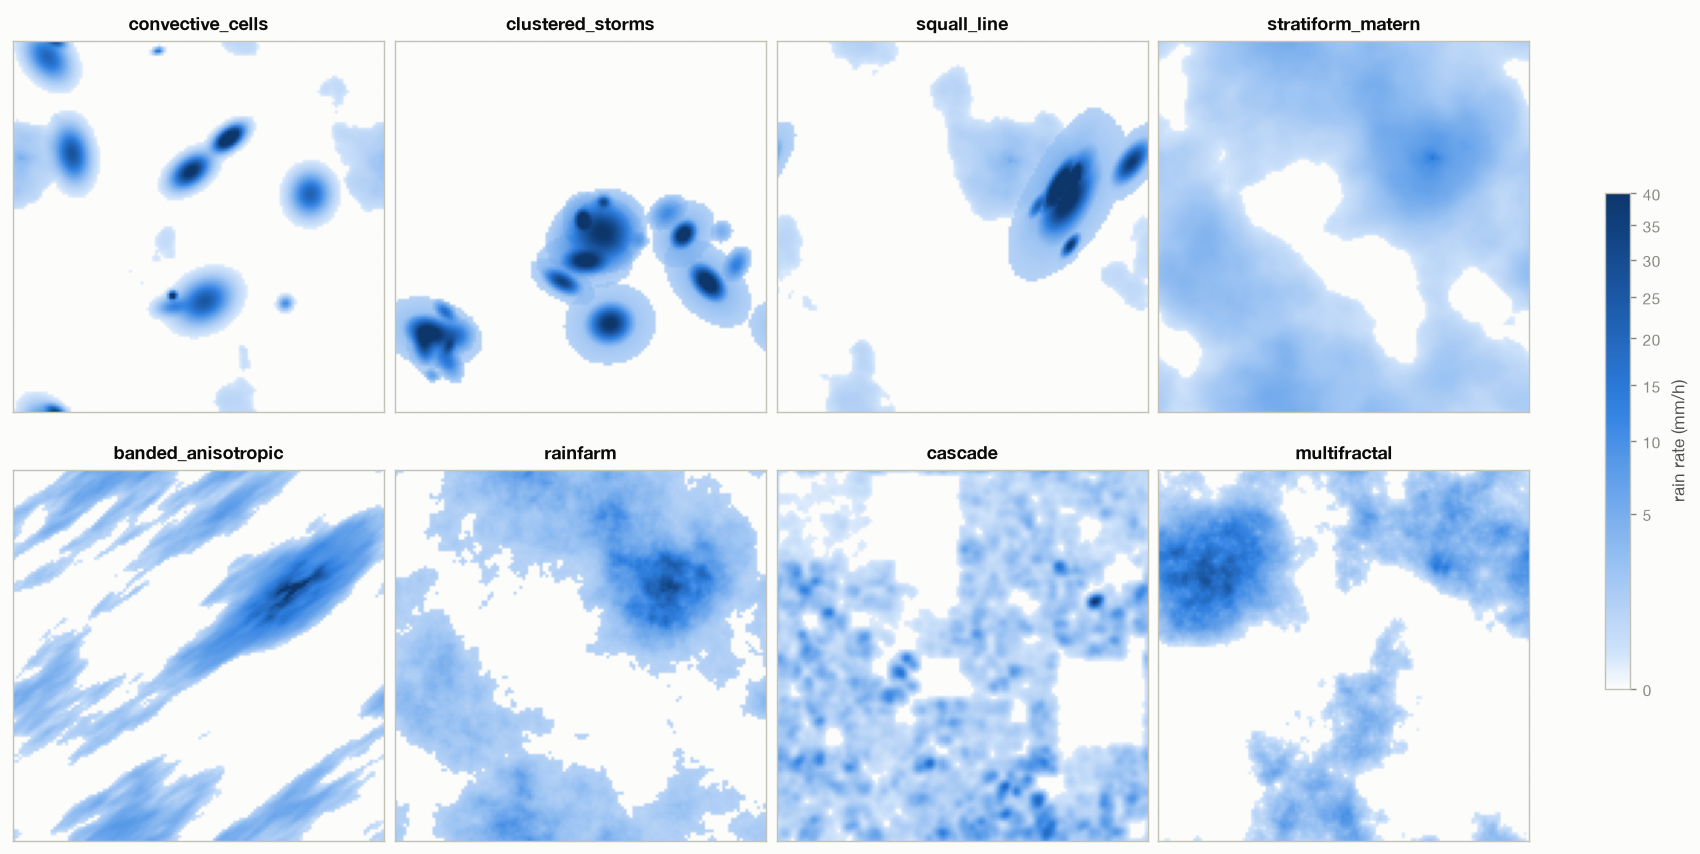

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(13, 6.6), layout="constrained")
for ax, (k, f) in zip(axes.ravel(), fields.items()):
    im = ax.imshow(f, origin="lower", extent=(0, 64, 0, 64), cmap=vs.CMAP_RAIN, norm=vs.rain_norm(40))
    ax.set_title(k, fontsize=10); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.6, label="rain rate (mm/h)");

## 2. One model, its parameters

The meta-Gaussian model separates **structure** (the covariance of a Gaussian field) from
**amounts** (the wet fraction and the distribution of wet values). Same seed, four covariances:

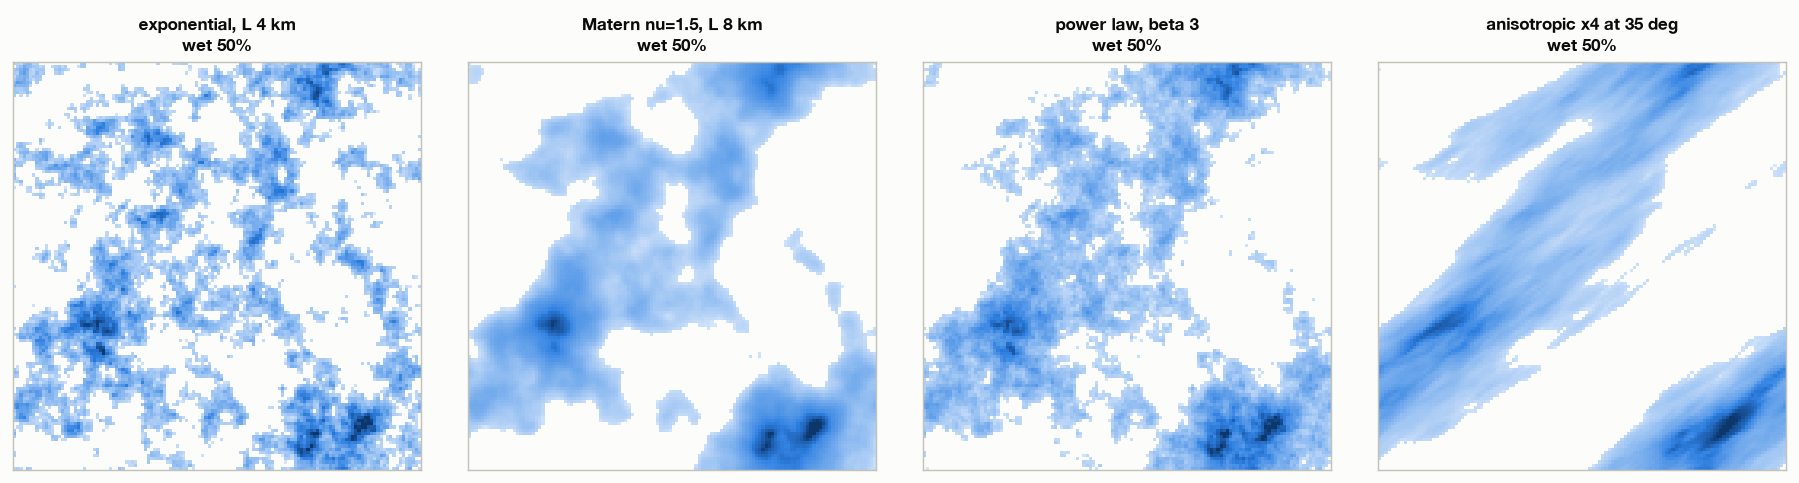

In [5]:
covs = {"exponential, L 4 km": dict(cov="exponential", length_km=4),
        "Matern nu=1.5, L 8 km": dict(cov="matern", nu=1.5, length_km=8),
        "power law, beta 3": dict(cov="powerlaw", beta=3.0),
        "anisotropic x4 at 35 deg": dict(cov="matern", length_km=6, anisotropy=4, angle_deg=35)}
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), layout="constrained")
for ax, (name, p) in zip(axes, covs.items()):
    f = gen.make("metagaussian", war=0.5, mean_wet_mm_h=3, seed=1, **p).build(grid)
    ax.imshow(f, origin="lower", extent=(0, 64, 0, 64), cmap=vs.CMAP_RAIN, norm=vs.rain_norm(30))
    ax.set_title(f"{name}\nwet {np.mean(f > 0.1):.0%}", fontsize=9.5); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

Cells: a Gaussian profile, the HyCell profile (Gaussian core and exponential skirt, Feral et al.
2003) and a small-scale texture that makes cells ragged down to the street scale.

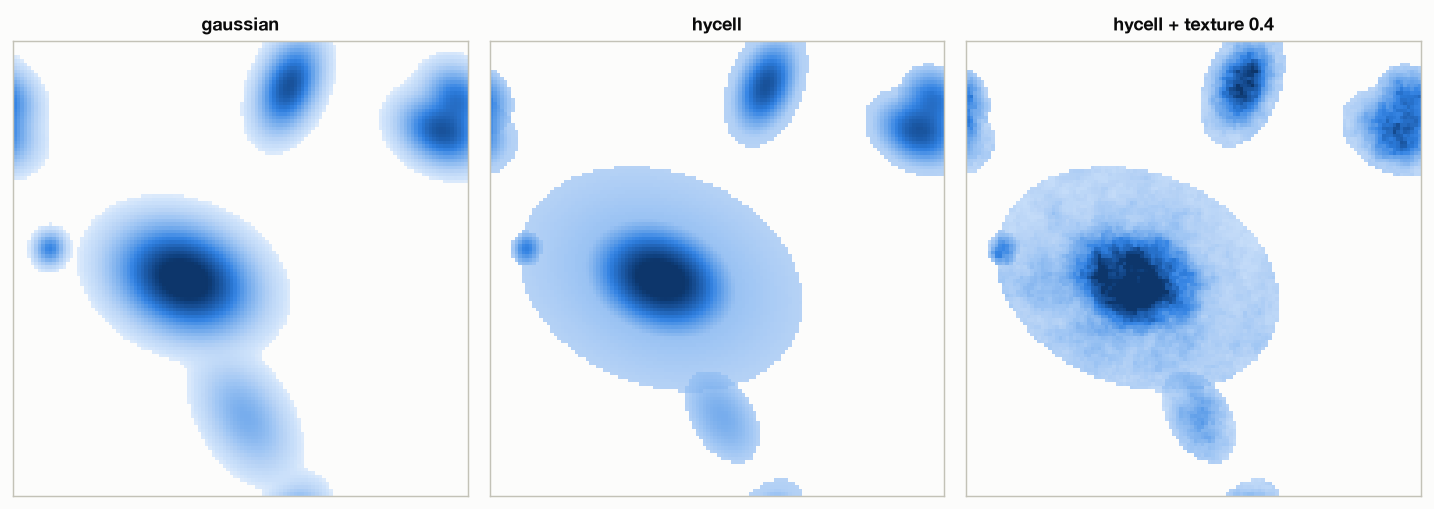

In [6]:
variants = {"gaussian": dict(profile="gaussian"), "hycell": dict(profile="hycell"),
            "hycell + texture 0.4": dict(profile="hycell", texture_strength=0.4)}
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), layout="constrained")
for ax, (name, p) in zip(axes, variants.items()):
    f = gen.make("gaussian_cells", n_cells=6, poisson=False, radius_km=3, seed=4, **p).build(grid)
    ax.imshow(f, origin="lower", extent=(0, 64, 0, 64), cmap=vs.CMAP_RAIN, norm=vs.rain_norm(40))
    ax.set_title(name, fontsize=10); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

## 3. Flows

Divergence-free velocity fields in km/h. The estimators of the nowcasting notebooks assume a
smooth motion; these test them where the motion is not uniform.

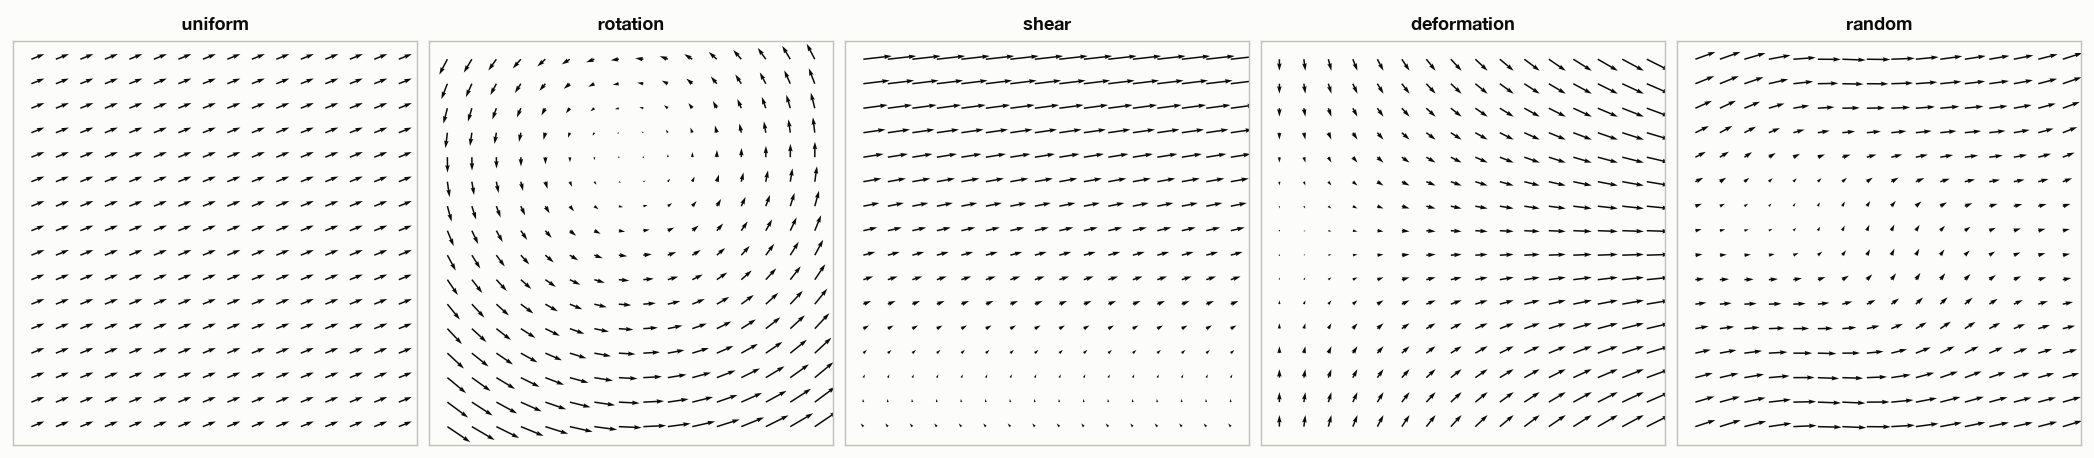

In [7]:
flows = {"uniform": fl.UniformFlow(mean=(25, 10)), "rotation": fl.RotationFlow(omega_deg_h=40, mean=(10, 0)),
         "shear": fl.ShearFlow(shear_per_h=0.8), "deformation": fl.DeformationFlow(rate_per_h=0.5),
         "random": fl.RandomFlow(rms_kmh=10, length_km=25, seed=2)}
g16 = Grid(n=16, dx_km=4.0)
fig, axes = plt.subplots(1, 5, figsize=(16, 3.4), layout="constrained")
for ax, (name, f) in zip(axes, flows.items()):
    f.prepare(64.0, Grid(n=64, dx_km=1.0))
    v = f.field(g16); x, y = g16.meshgrid()
    ax.quiver(x, y, v[0], v[1], color=vs.INK_PRIMARY); ax.set_title(name, fontsize=10)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])

## 4. Moving and evolving

`spacetime.simulate` moves any generator in any flow, with one of four evolutions. Each
sequence carries its true velocity, and `predictability(h)` is the correlation between the
field `h` steps ahead and the present field carried there by the true flow - what an
advection nowcast with perfect motion could reach.

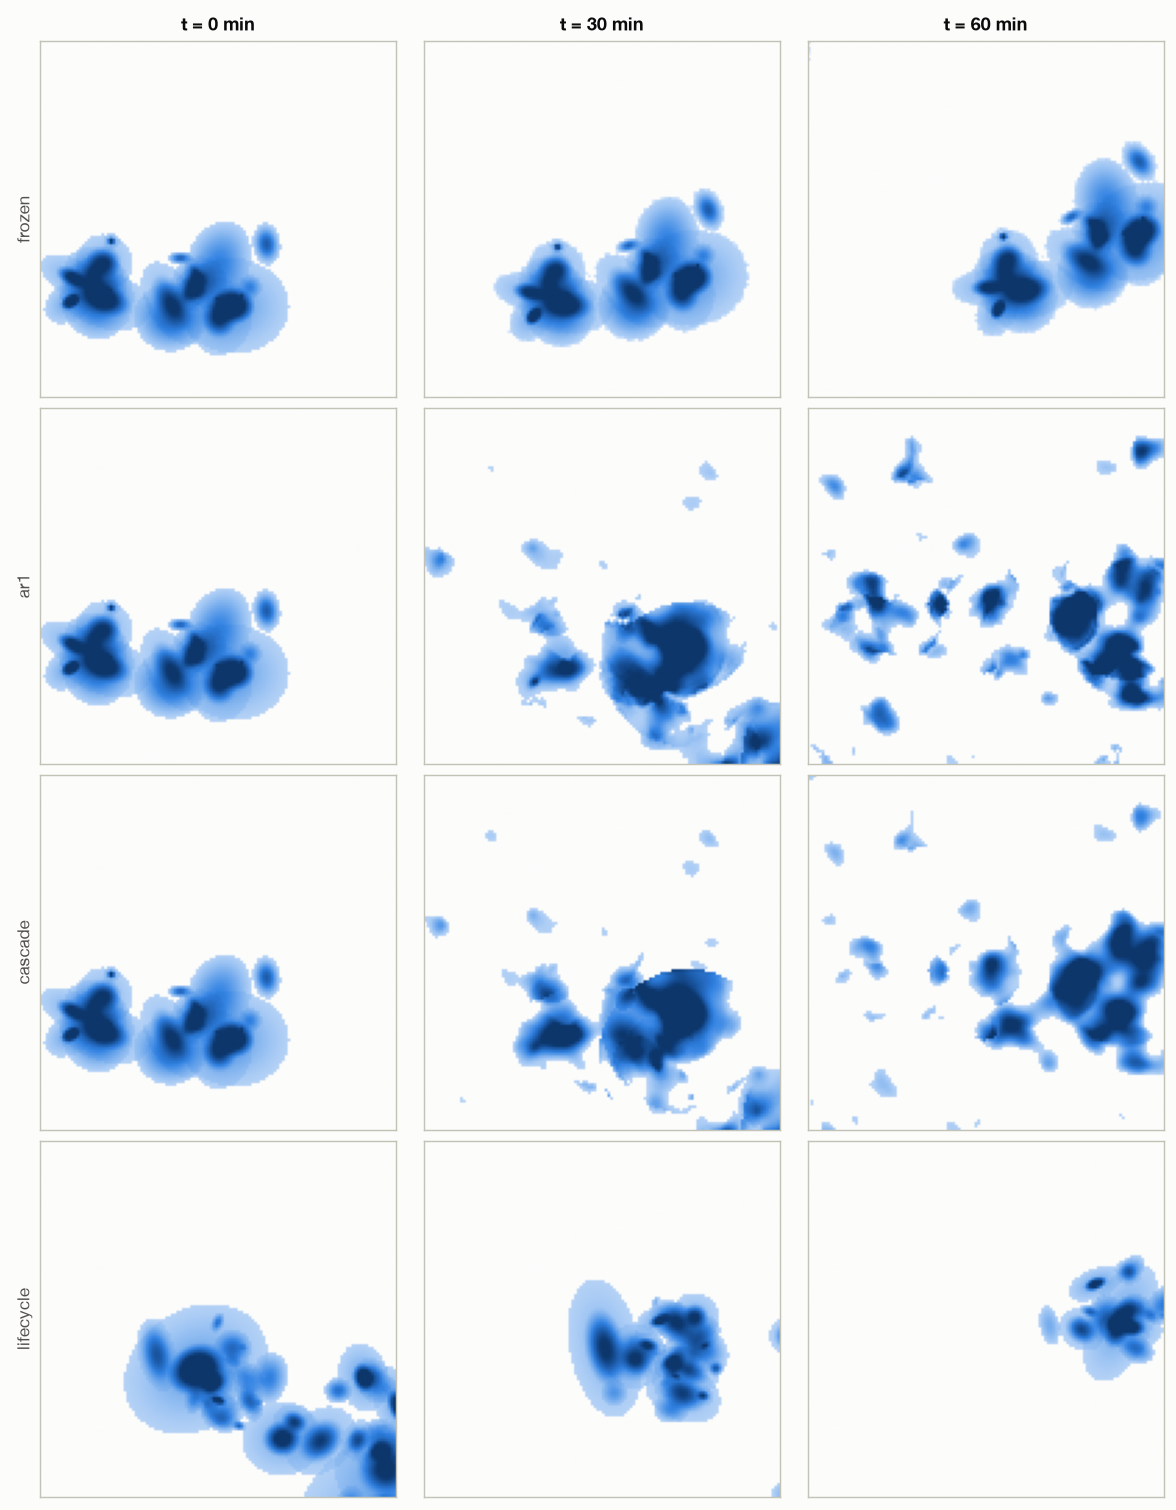

In [8]:
model = gen.make("clustered_storms", seed=5)
flow = fl.RotationFlow(omega_deg_h=30, mean=(20.0, 5.0))
seqs = {ev: st.simulate(model, grid, 13, 5.0, flow=flow, evolution=ev, tau_min=60, lifetime_min=60, seed=5)
        for ev in ("frozen", "ar1", "cascade", "lifecycle")}
fig, axes = plt.subplots(4, 3, figsize=(9, 11.5), layout="constrained")
for i, (ev, s) in enumerate(seqs.items()):
    for j, t in enumerate((0, 6, 12)):
        ax = axes[i, j]
        ax.imshow(s.frames[t], origin="lower", extent=(0, 64, 0, 64), cmap=vs.CMAP_RAIN, norm=vs.rain_norm(40))
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if i == 0: ax.set_title(f"t = {5 * t} min", fontsize=10)
        if j == 0: ax.set_ylabel(ev)

In [9]:
pd.DataFrame({ev: {f"{5 * h} min": round(s.predictability(h), 2) for h in (3, 6, 12)} for ev, s in seqs.items()}).T

,15 min,30 min,60 min
frozen,1.00,1.00,1.00
ar1,0.74,0.53,0.20
cascade,0.84,0.72,0.45
lifecycle,0.81,0.63,0.48


Frozen rain is perfectly predictable by its motion; the cascade evolution keeps more than AR(1)
at the same `tau` because only small scales decorrelate fast. The project's table over all
generators (4 seeds each):

In [10]:
pd.read_csv(TAB / "predictability.csv").round(2)

,model,evolution,r30,r60
0,banded_anisotropic,ar1,0.49,0.28
1,banded_anisotropic,cascade,0.59,0.36
2,cascade,ar1,0.41,0.28
3,cascade,cascade,0.41,0.27
4,clustered_storms,ar1,0.41,0.28
5,clustered_storms,cascade,0.59,0.52
6,clustered_storms,lifecycle,0.53,0.52
7,convective_cells,ar1,0.40,0.17
8,convective_cells,cascade,0.51,0.29
9,convective_cells,lifecycle,0.39,0.10


## 5. A physical model

`cloud_model.WarmRainModel`: vapour, cloud water and rain water paths, condensation in
thermals that are born, strengthen and decay, Kessler autoconversion and accretion,
evaporation and fall-out. Rain appears after the cloud, and decays by itself.

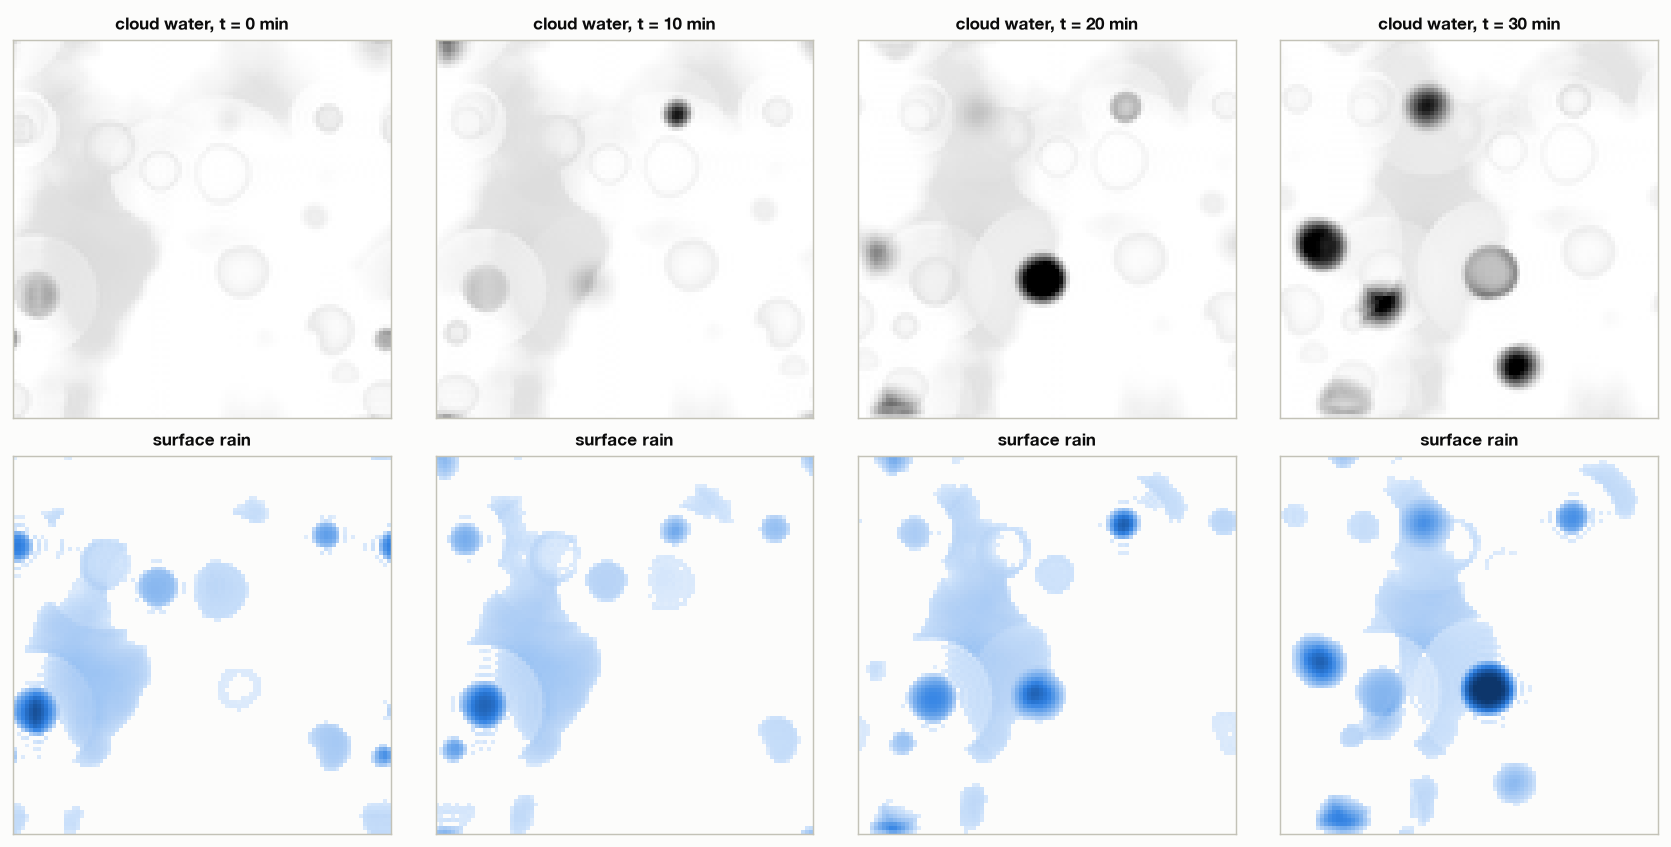

In [11]:
from core.simulation.cloud_model import WarmRainModel
cm = WarmRainModel(seed=1).simulate(Grid(n=96, dx_km=0.5), 7, 5.0)
fig, axes = plt.subplots(2, 4, figsize=(13, 6.4), layout="constrained")
for j, t in enumerate((0, 2, 4, 6)):
    axes[0, j].imshow(cm.extras["cloud_water"][t], origin="lower", cmap="Greys", vmin=0, vmax=3)
    axes[0, j].set_title(f"cloud water, t = {5 * t} min", fontsize=9.5)
    axes[1, j].imshow(cm.frames[t], origin="lower", cmap=vs.CMAP_RAIN, norm=vs.rain_norm(40))
    axes[1, j].set_title("surface rain", fontsize=9.5)
for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

## 6. Other fields and 1-D fields

`met_fields` (temperature with a cold pool under rain, humidity, pressure, wind) and
`fields_1d` (Bartlett-Lewis and Neyman-Scott point series; the transect a link averages).

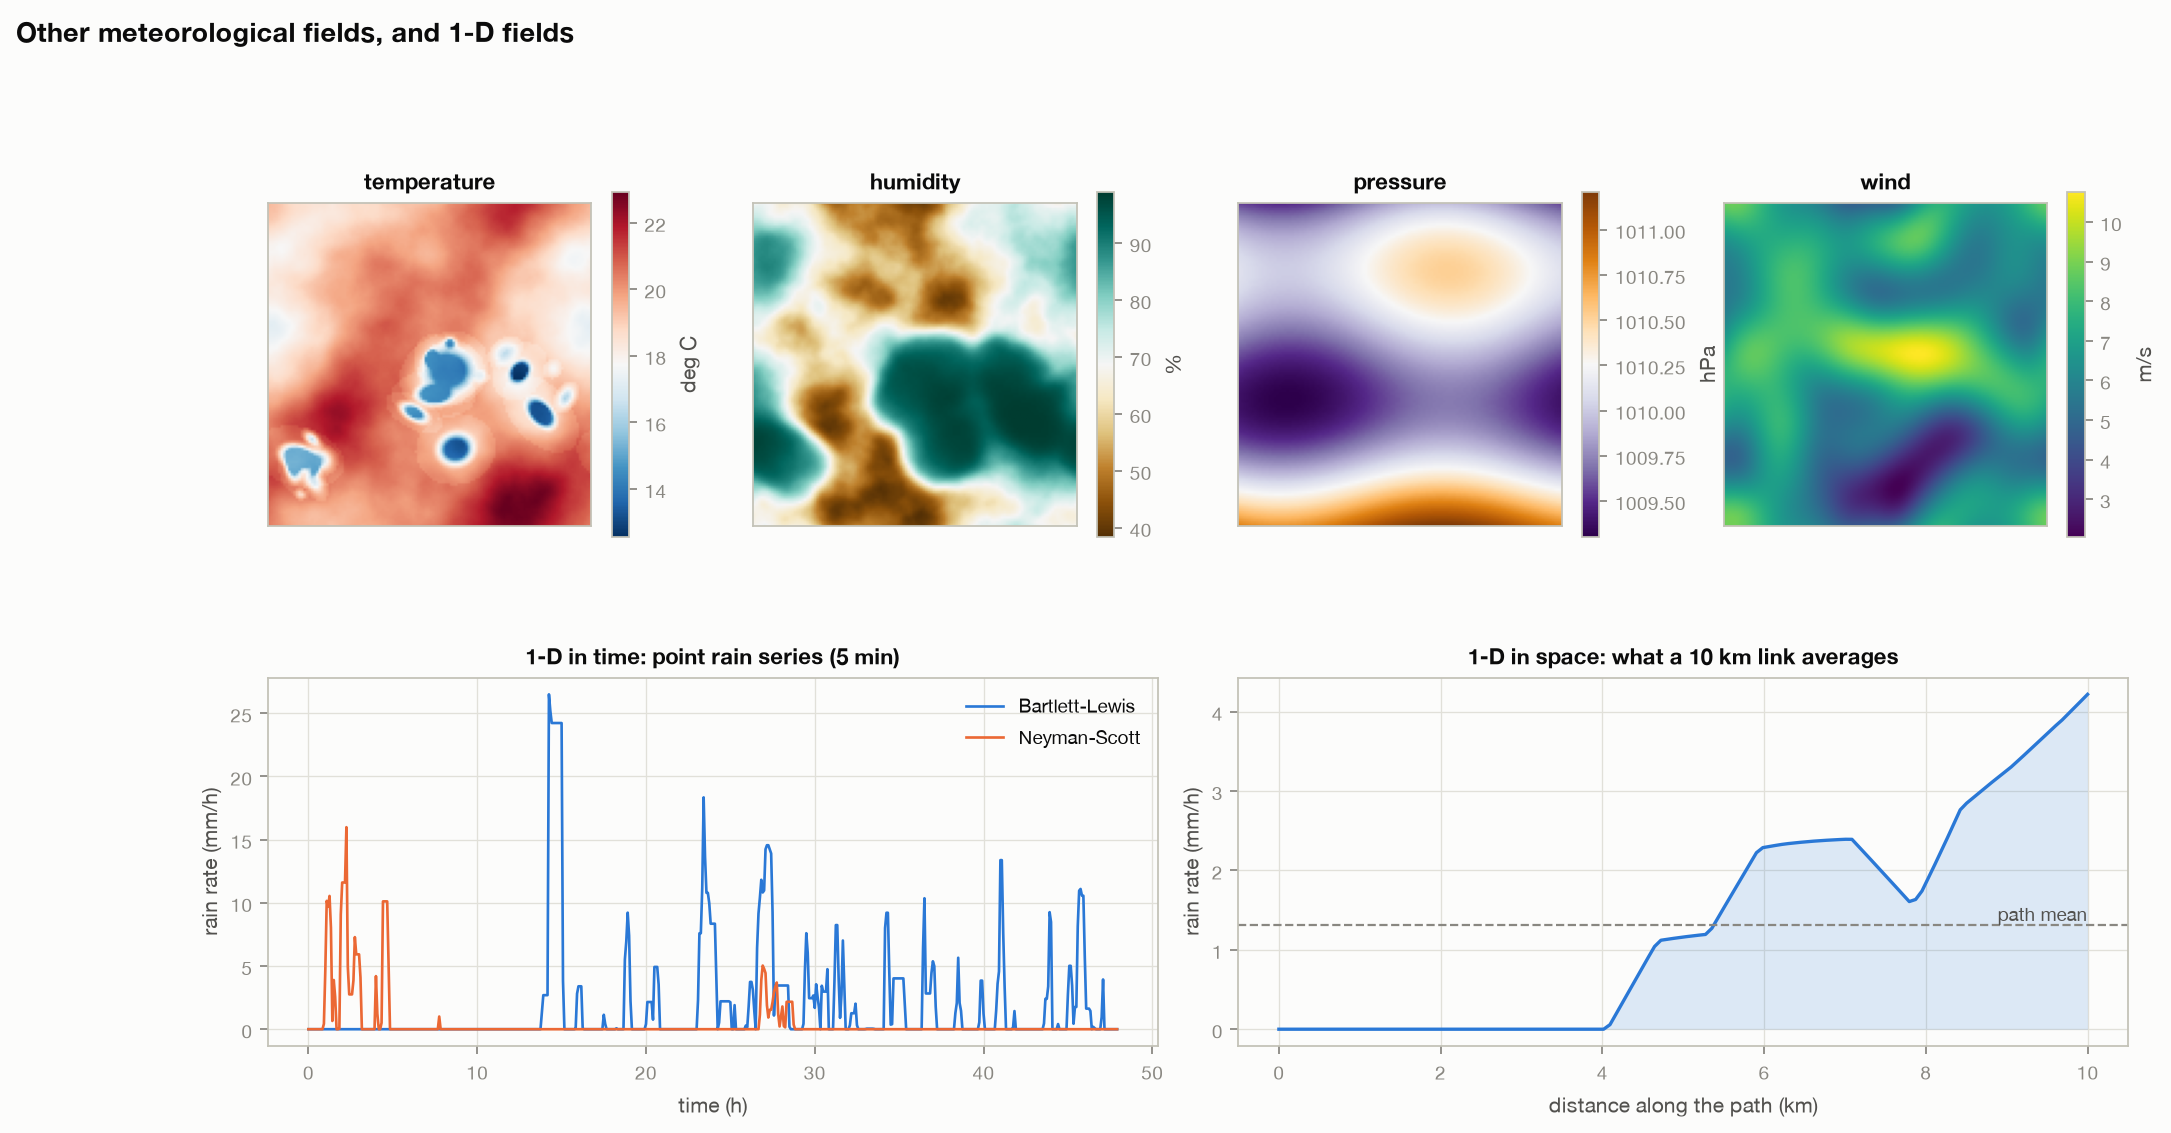

In [12]:
display(Image(str(FIG / "fig03_other_fields.png")))